In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read all CSV files
cam1_gt1 = pd.read_csv('pose_gtcam1_cam1.csv')
cam1_gt22 = pd.read_csv('pose_gtcam22_cam1.csv')
cam22_gt1 = pd.read_csv('pose_gtcam1_cam22.csv')
cam22_gt22 = pd.read_csv('pose_gtcam22_cam22.csv')

# Set style for better visualization
plt.style.use('default')

# Define colors for consistency
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']


FileNotFoundError: [Errno 2] No such file or directory: 'pose_gtcam1_cam1.csv'

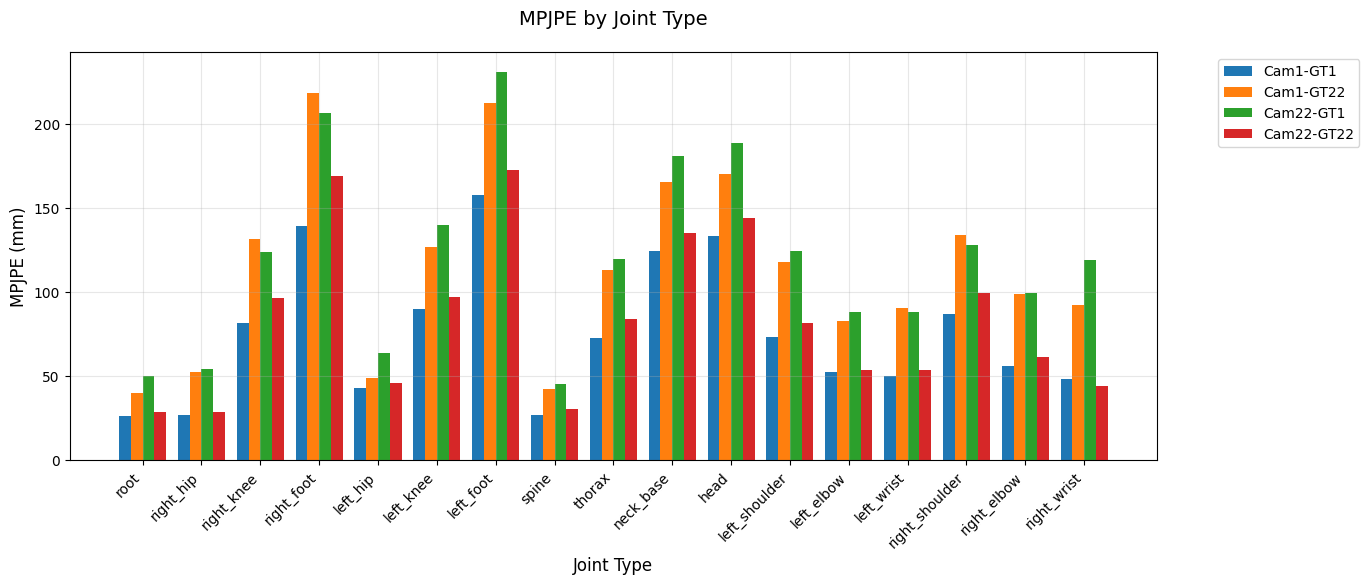

In [30]:
# Function to extract joint names and their MPJPEs from all frames (calculate summary ourselves)
def get_joint_mpjpes(df):
    # Get columns that start with 'mpjpe_' but not 'mpjpe_mm'
    joint_cols = [col for col in df.columns if col.startswith('mpjpe_') and not col.endswith('_mm')]
    
    # Filter out any non-numeric frame_idx rows and convert to numeric
    numeric_data = df[pd.to_numeric(df['frame_idx'], errors='coerce').notna()]
    
    # Extract joint names and calculate mean values across all frames
    joints = [col.replace('mpjpe_', '') for col in joint_cols]
    mpjpes = [numeric_data[col].mean() for col in joint_cols]
    
    return joints, mpjpes

# Create figure for bar chart
plt.figure(figsize=(15, 6))

# Plot bars for each camera-GT combination
joints, mpjpes_cam1_gt1 = get_joint_mpjpes(cam1_gt1)
joints, mpjpes_cam1_gt22 = get_joint_mpjpes(cam1_gt22)
joints, mpjpes_cam22_gt1 = get_joint_mpjpes(cam22_gt1)
joints, mpjpes_cam22_gt22 = get_joint_mpjpes(cam22_gt22)

x = np.arange(len(joints))
width = 0.2

plt.bar(x - 1.5*width, mpjpes_cam1_gt1, width, label='Cam1-GT1', color=colors[0])
plt.bar(x - 0.5*width, mpjpes_cam1_gt22, width, label='Cam1-GT22', color=colors[1])
plt.bar(x + 0.5*width, mpjpes_cam22_gt1, width, label='Cam22-GT1', color=colors[2])
plt.bar(x + 1.5*width, mpjpes_cam22_gt22, width, label='Cam22-GT22', color=colors[3])

plt.xlabel('Joint Type', fontsize=12)
plt.ylabel('MPJPE (mm)', fontsize=12)
plt.title('MPJPE by Joint Type', fontsize=14, pad=20)
plt.xticks(x, joints, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.subplots_adjust(bottom=0.2, right=0.85)
plt.show()


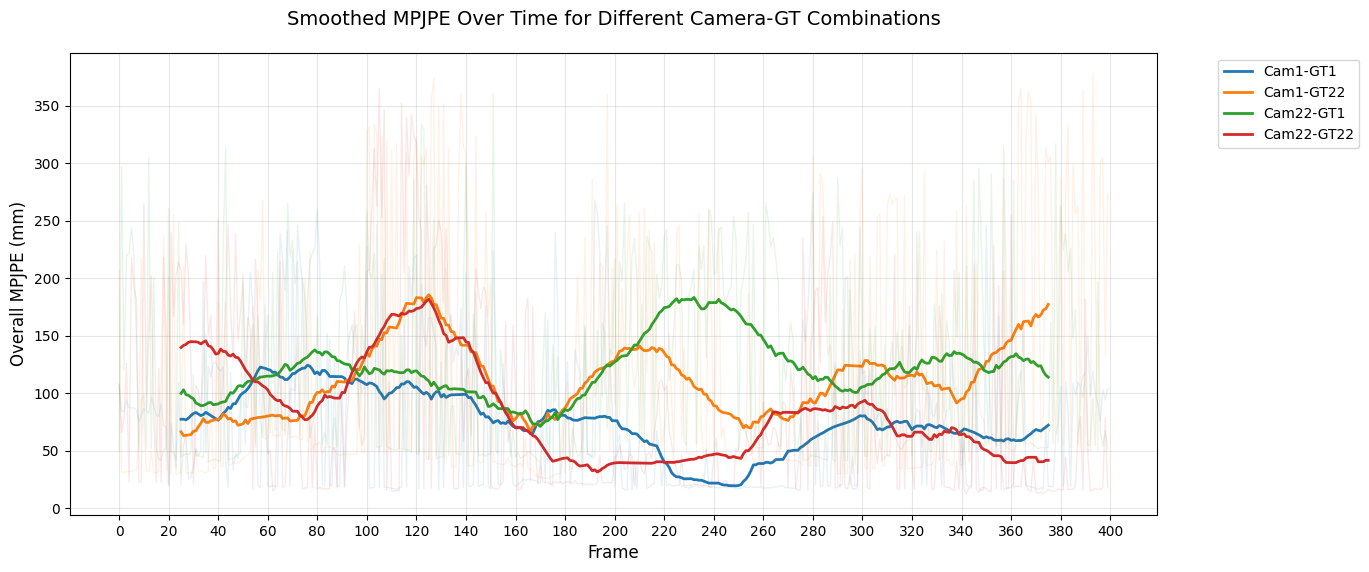

In [28]:
# Create figure for line plot
plt.figure(figsize=(15, 6))

# Get frame-by-frame data (excluding summary row)
def get_frame_data(df):
    df['frame_idx'] = df['frame_idx'].astype(int)
    frame_data = df[df['frame_idx'] != 'SUMMARY'].sort_values('frame_idx')
    # Apply rolling average smoothing (window size of 15 frames)
    frame_data['smoothed_mpjpe'] = frame_data['overall_mpjpe'].rolling(window=50, center=True).mean()
    return frame_data

# Plot line for each camera-GT combination
frame_data_cam1_gt1 = get_frame_data(cam1_gt1)
frame_data_cam1_gt22 = get_frame_data(cam1_gt22)
frame_data_cam22_gt1 = get_frame_data(cam22_gt1)
frame_data_cam22_gt22 = get_frame_data(cam22_gt22)

# Plot smoothed lines
plt.plot(frame_data_cam1_gt1['frame_idx'], frame_data_cam1_gt1['smoothed_mpjpe'], 
         label='Cam1-GT1', color=colors[0], linewidth=2)
plt.plot(frame_data_cam1_gt22['frame_idx'], frame_data_cam1_gt22['smoothed_mpjpe'], 
         label='Cam1-GT22', color=colors[1], linewidth=2)
plt.plot(frame_data_cam22_gt1['frame_idx'], frame_data_cam22_gt1['smoothed_mpjpe'], 
         label='Cam22-GT1', color=colors[2], linewidth=2)
plt.plot(frame_data_cam22_gt22['frame_idx'], frame_data_cam22_gt22['smoothed_mpjpe'], 
         label='Cam22-GT22', color=colors[3], linewidth=2)

# Optionally plot original data with low opacity to show the smoothing effect
plt.plot(frame_data_cam1_gt1['frame_idx'], frame_data_cam1_gt1['overall_mpjpe'], 
         color=colors[0], alpha=0.1, linewidth=1)
plt.plot(frame_data_cam1_gt22['frame_idx'], frame_data_cam1_gt22['overall_mpjpe'], 
         color=colors[1], alpha=0.1, linewidth=1)
plt.plot(frame_data_cam22_gt1['frame_idx'], frame_data_cam22_gt1['overall_mpjpe'], 
         color=colors[2], alpha=0.1, linewidth=1)
plt.plot(frame_data_cam22_gt22['frame_idx'], frame_data_cam22_gt22['overall_mpjpe'], 
         color=colors[3], alpha=0.1, linewidth=1)

plt.xlabel('Frame', fontsize=12)
plt.ylabel('Overall MPJPE (mm)', fontsize=12)
plt.title('Smoothed MPJPE Over Time for Different Camera-GT Combinations', fontsize=14, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Set x-axis ticks at regular intervals
plt.xticks(range(0, 401, 20))

# Adjust layout to prevent label cutoff
plt.subplots_adjust(right=0.85)
plt.show()
